# Icescopy counts to INP per litre of air with INP-toolkit

Load counts, assign the sample and blank, calculate concentrations, and compare
MLE and Average with the supplied OLAF result. The final section shows the
same workflow in one call.

Run from this repository or its `notebook` folder.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

# Import the package from this checkout.
project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(project_root / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import inptk

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})


## 1. Choose the data and settings

`Sample_0`–`Sample_4` belong to one original sample; `Sample_5` is the blank.
The export supplies dilution factors and 50 µL droplet volumes.

Select counts on a 0.5 °C grid before calculating concentrations. Leave the
start and end as `None` to use the measured temperature limits without rounding.
`latest` uses the last observation at or warmer than each grid temperature.


In [2]:
DATA_DIR = Path("/Volumes/Hailstone Data/Mentor data from Carson/(M1) 08.12.25 base rerun")
DATA_PATH = DATA_DIR / "freeze_count_timeseries.csv"  # A .icescopy project also works.
REFERENCE_PATH = DATA_DIR / "INPs_L_frozen_at_temp_reviewed_crg m1 08.12.25 base rerun.csv"

SAMPLE_INPUTS = [f"Sample_{i}" for i in range(5)]
BLANK_INPUT = "Sample_5"
SAMPLE_ID = "CRG_M1"
CYCLE_ID = "0"
CURVES = {SAMPLE_ID: {"inputs": SAMPLE_INPUTS, "cycle": CYCLE_ID}}

METHOD = "average"  # Or "mle" for the individual and all-in-one examples.
GRID = {
    "temperature_step_C": 0.5,
    "temperature_start_C": None,
    "temperature_end_C": None,
    "temperature_method": "latest",
}
FIT_STEP_C = 0.5  # MLE curve resolution.
DECREASE_POLICY = "skip_decreases"  # Keep later points when concentration recovers.
TEMPERATURE_XLIM = (-30, -5)


## 2. Read the counts and assign the blank

The CSV lacks the air volume, suspension volume, and filter fraction. Read those
from the matching OLAF reference. Assign the blank explicitly and set its dilution
to 1. All count rows are used, including rows without an image ID.


In [3]:
reference_file = inptk.read_csu_csv(REFERENCE_PATH)
reference = reference_file.table

air_metadata = {
    key: reference_file.metadata[key]
    for key in ("air_volume_L", "suspension_volume_mL", "filter_fraction_used")
}
metadata = {name: dict(air_metadata) for name in SAMPLE_INPUTS}
metadata[BLANK_INPUT] = {"sample_type": "other", "dilution": 1}

experiment = inptk.read_icescopy(
    DATA_PATH,
    metadata=metadata,
    sample_map={**dict.fromkeys(SAMPLE_INPUTS, SAMPLE_ID), BLANK_INPUT: "water"},
    water_blank_map={name: [BLANK_INPUT] for name in SAMPLE_INPUTS},
    run_id="M1-base-rerun",
)
experiment.counts.to_dataframe().head()


,sample_id,temperature_C,n_total,n_frozen,fraction_frozen,time_s,picture_id,measurement_id,run_id,cycle_id,observation_id
0,CRG_M1,20.634,32.0,0.0,0.0,0.00,NaN,Sample_0,M1-base-rerun,0,0
1,CRG_M1,20.632,32.0,0.0,0.0,0.34,NaN,Sample_0,M1-base-rerun,0,1
2,CRG_M1,20.634,32.0,0.0,0.0,1.27,NaN,Sample_0,M1-base-rerun,0,2
3,CRG_M1,20.615,32.0,0.0,0.0,2.27,NaN,Sample_0,M1-base-rerun,0,3
4,CRG_M1,20.610,32.0,0.0,0.0,3.27,NaN,Sample_0,M1-base-rerun,0,4


## 3. Inspect counts and frozen fractions

`frozen_fraction()` divides frozen counts by total counts at each original
observation. Repeated cycles remain separate.


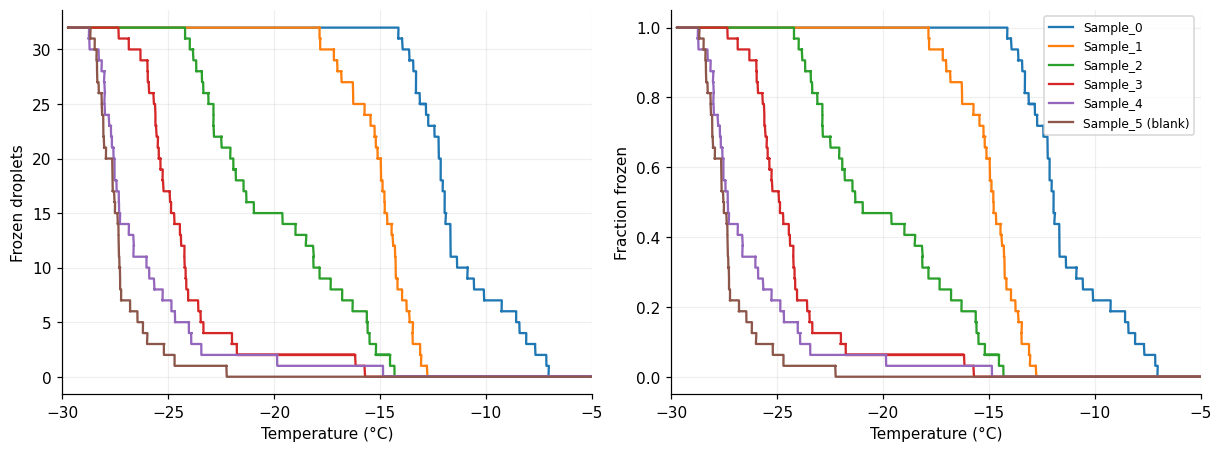

In [4]:
fractions = inptk.frozen_fraction(experiment)
observed = fractions.select(cycle_id=CYCLE_ID).to_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for name, frame in observed.groupby("measurement_id", sort=False):
    label = f"{name} (blank)" if name == BLANK_INPUT else name
    axes[0].plot(frame.temperature_C, frame.n_frozen, label=label)
    axes[1].plot(frame.temperature_C, frame.fraction_frozen, label=label)
for ax in axes:
    ax.set(xlabel="Temperature (°C)", xlim=TEMPERATURE_XLIM)
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Frozen droplets")
axes[1].set_ylabel("Fraction frozen")
axes[1].legend(fontsize=8)
plt.show()


## 4. Choose the temperature ranges

Average uses automatic limits: exhaust the least diluted input, then move to
the next. Require at least 3 liquid wells, and at least 3 frozen wells for later
inputs. The first input keeps its initial observations.

MLE uses the manually chosen limits below. `max_C` is the warmest allowed
temperature for that input; omitted limits leave the corresponding end open.


In [5]:
average_limits = inptk.suggest_temperature_ranges(
    experiment, curves=CURVES, min_frozen=3, min_unfrozen=3,
)
ranges = {
    "average": average_limits.temperature_ranges_C,
    "mle": {
        "Sample_1": {"max_C": -10},
        "Sample_2": {"max_C": -15},
        "Sample_3": {"max_C": -20},
        "Sample_4": {"max_C": -25},
    },
}
pd.DataFrame.from_dict(ranges[METHOD], orient="index")


,min_C,max_C
Sample_0,-13.621,20.655
Sample_1,-17.164,-13.622
Sample_2,-23.808,-17.166
Sample_3,-26.308,-23.817
Sample_4,-28.285,-26.310


## 5. Calculate each input separately

Calculate concentration in the original suspension, then convert to INP per
litre of air. The assigned raw blank and its uncertainty are included.


In [6]:
individual = inptk.cumulative_spectrum(
    fractions, experiment=experiment, method=METHOD,
    **GRID,
    fit_step_C=FIT_STEP_C if METHOD == "mle" else None,
    temperature_ranges_C=ranges[METHOD],
)
individual_air = inptk.convert_concentration(
    individual, experiment.samples, basis="sampled_air",
)
individual_air.to_dataframe().head()


,measurement_id,run_id,cycle_id,sample_id,temperature_C,n_total,n_frozen,fraction_frozen,time_s,picture_id,...,dilution_fold,water_blank_ids,source_observations,uncertainty_method,correction_state,at_zero_boundary,is_extrapolated,water_blank_observations,blank_n_frozen,blank_n_total
0,Sample_0,M1-base-rerun,0,CRG_M1,20.655,32.0,0.0,0.0,5.27,NaN,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,"[{""measurement_id"": ""Sample_5"", ""run_id"": ""M1-...",0.0,32.0
1,Sample_0,M1-base-rerun,0,CRG_M1,20.155,32.0,0.0,0.0,286.27,NaN,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,"[{""measurement_id"": ""Sample_5"", ""run_id"": ""M1-...",0.0,32.0
2,Sample_0,M1-base-rerun,0,CRG_M1,19.655,32.0,0.0,0.0,382.27,NaN,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,"[{""measurement_id"": ""Sample_5"", ""run_id"": ""M1-...",0.0,32.0
3,Sample_0,M1-base-rerun,0,CRG_M1,19.155,32.0,0.0,0.0,452.27,NaN,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,"[{""measurement_id"": ""Sample_5"", ""run_id"": ""M1-...",0.0,32.0
4,Sample_0,M1-base-rerun,0,CRG_M1,18.655,32.0,0.0,0.0,513.27,NaN,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,"[{""measurement_id"": ""Sample_5"", ""run_id"": ""M1-...",0.0,32.0


The plotting helper draws concentrations and optional uncertainty shading.
Zero and non-finite values cannot be drawn on a log axis. Separate segments
keep lines from crossing excluded parts of a curve.


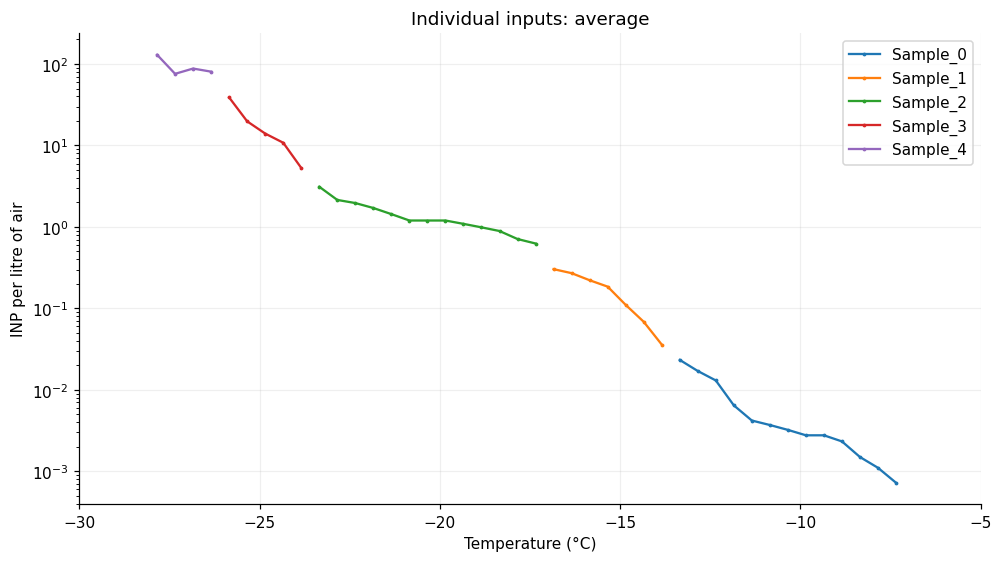

In [7]:
def plot_spectrum(ax, frame, label, color, uncertainty=False):
    segments = frame.groupby("segment_id", sort=False) if "segment_id" in frame else [(0, frame)]
    for i, (_, segment) in enumerate(segments):
        concentration = segment.concentration
        visible = np.isfinite(concentration) & (concentration > 0)
        ax.plot(segment.temperature_C, concentration.where(visible), ".-",
                color=color, label=label if i == 0 else None, markersize=3)
        if uncertainty:
            lower = concentration - segment.lower_error
            upper = concentration + segment.upper_error
            band = visible & (lower > 0) & np.isfinite(lower) & np.isfinite(upper)
            ax.fill_between(segment.temperature_C, lower.where(band), upper.where(band),
                            color=color, alpha=0.15)

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
for i, (name, frame) in enumerate(
    individual_air.select(sample_id=SAMPLE_ID, cycle_id=CYCLE_ID).to_dataframe()
    .groupby("measurement_id", sort=False)
):
    plot_spectrum(ax, frame, name, f"C{i}")
ax.set(yscale="log", xlabel="Temperature (°C)", ylabel="INP per litre of air",
       xlim=TEMPERATURE_XLIM, title=f"Individual inputs: {METHOD}")
ax.legend()
ax.grid(alpha=0.2)
plt.show()


## 6. Combine inputs, step by step

MLE fits the sample and blank freezing histories together, with a monotone
sample curve. Average estimates concentration at each temperature; where input
ranges overlap, it takes an equal-weight mean. Here the automatic Average
limits select one dilution at a time.

The steps are estimation, conversion to air units, and final point selection.
`skip_decreases` removes dips and keeps later points when concentration recovers.
The results stay on the initial analysis grid.


In [8]:
combined_air = {}
for method in ("mle", "average"):
    suspension = inptk.estimate_concentration(
        fractions, experiment=experiment, method=method, curves=CURVES,
        **GRID,
        fit_step_C=FIT_STEP_C if method == "mle" else None,
        temperature_ranges_C=ranges[method],
    )
    air = inptk.convert_concentration(
        suspension, experiment.samples, basis="sampled_air",
    )
    combined_air[method] = inptk.finalize_spectrum(
        air, decrease_policy=DECREASE_POLICY,
    )

combined_air[METHOD].to_dataframe().head()


,sample_id,curve_id,point_id,point_order,temperature_C,alignment,concentration,lower_error,upper_error,unit,...,dilution_fold,water_blank_ids,source_observations,uncertainty_method,correction_state,at_zero_boundary,is_extrapolated,used_in_final,final_selection_status,segment_id
0,CRG_M1,CRG_M1,point:0,0,20.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
1,CRG_M1,CRG_M1,point:1,1,20.155,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
2,CRG_M1,CRG_M1,point:2,2,19.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
3,CRG_M1,CRG_M1,point:3,3,19.155,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
4,CRG_M1,CRG_M1,point:4,4,18.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0


## 7. Compare with OLAF

Plot the calculated grid points directly. Shading shows approximate 95%
intervals at each temperature, not a 95% band for the entire curve. Bounds
reaching zero cannot be shaded on this log axis.


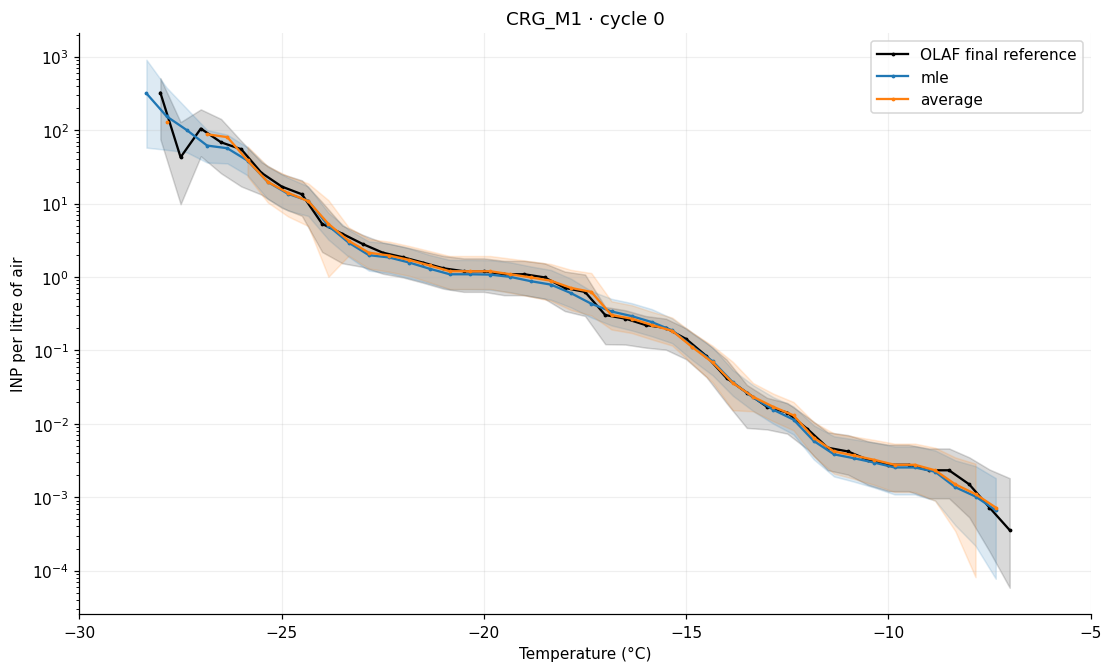

In [9]:
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
plot_spectrum(ax, reference, "OLAF final reference", "black", uncertainty=True)
for i, (method, table) in enumerate(combined_air.items()):
    plot_spectrum(ax, table.to_dataframe(), method, f"C{i}", uncertainty=True)
ax.set(yscale="log", xlabel="Temperature (°C)", ylabel="INP per litre of air",
       xlim=TEMPERATURE_XLIM, title=f"{SAMPLE_ID} · cycle {CYCLE_ID}")
ax.legend()
ax.grid(alpha=0.2)
plt.show()


## 8. Run the analysis in one call

`analyze_concentration()` runs the same calculation steps. Give each output
curve a name and its input list. Here we request the combined curve and a
separate curve for each sample input.


In [10]:
output_curves = {
    **CURVES,
    **{name: {"inputs": [name], "cycle": CYCLE_ID} for name in SAMPLE_INPUTS},
}
result = inptk.analyze_concentration(
    experiment, method=METHOD, curves=output_curves,
    **GRID,
    fit_step_C=FIT_STEP_C if METHOD == "mle" else None,
    temperature_ranges_C=ranges[METHOD],
    output_basis="sampled_air", decrease_policy=DECREASE_POLICY,
)
result.curves[SAMPLE_ID].cumulative.to_dataframe().head()


,sample_id,curve_id,point_id,point_order,temperature_C,alignment,concentration,lower_error,upper_error,unit,...,dilution_fold,water_blank_ids,source_observations,uncertainty_method,correction_state,at_zero_boundary,is_extrapolated,used_in_final,final_selection_status,segment_id
0,CRG_M1,CRG_M1,point:0,0,20.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
1,CRG_M1,CRG_M1,point:1,1,20.155,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
2,CRG_M1,CRG_M1,point:2,2,19.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
3,CRG_M1,CRG_M1,point:3,3,19.155,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0
4,CRG_M1,CRG_M1,point:4,4,18.655,latest,0.0,0.0,0.000673,INP_per_L_air,...,1.0,"[""Sample_5""]","[{""measurement_id"": ""Sample_0"", ""run_id"": ""M1-...",joint_sample_water_blank_profile_likelihood,water_blank_corrected,True,False,True,kept,0


Use `result.curves["Sample_0"].cumulative` for an individual curve,
`result.curves[SAMPLE_ID].excluded` for excluded points, and `result.counts`
or `result.frozen_fraction` for the original observations.


## 9. Save when needed

Uncomment these lines to save the result and the combined concentration table.


In [11]:
# result.save("m1_analysis.inptk")
# result.export_csv("m1_concentration_air.csv", curve_id=SAMPLE_ID)
